In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

from sklearn.metrics import mean_absolute_error, mean_squared_error


#  Load dataset

In [2]:
df = pd.read_csv(r"C:\Users\Shramanth P Acharya\Unified Mentor Private\coffee_demand_forecasting\data\coffee_sales.csv.csv")

df.head()


,transaction_id,year,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2025,7:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2025,7:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2025,7:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2025,7:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2025,7:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_id    149116 non-null  int64  
 1   year              149116 non-null  int64  
 2   transaction_time  149116 non-null  object 
 3   transaction_qty   149116 non-null  int64  
 4   store_id          149116 non-null  int64  
 5   store_location    149116 non-null  object 
 6   product_id        149116 non-null  int64  
 7   unit_price        149116 non-null  float64
 8   product_category  149116 non-null  object 
 9   product_type      149116 non-null  object 
 10  product_detail    149116 non-null  object 
dtypes: float64(1), int64(5), object(5)
memory usage: 12.5+ MB


# Data Cleaning & Time Processing

In [4]:
# df['transaction_time'] = pd.to_datetime(df['transaction_time'])
df['transaction_time'] = pd.to_datetime(df['transaction_time'],)

df['hour'] = df['transaction_time'].dt.hour
df['date'] = df['transaction_time'].dt.date


C:\Users\Shramanth P Acharya\AppData\Local\Temp\ipykernel_19752\2533868155.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['transaction_time'] = pd.to_datetime(df['transaction_time'],)


In [5]:
# Create Revenue Column
df['revenue'] = df['transaction_qty'] * df['unit_price']
# Basic Validation
df = df[df['transaction_qty'] > 0]
df = df[df['unit_price'] > 0]


# Time-Series Aggregation

In [6]:
hourly_sales = (
    df.groupby(['store_id', 'date', 'hour'])
      .agg(
          quantity=('transaction_qty', 'sum'),
          revenue=('revenue', 'sum')
      )
      .reset_index()
)

hourly_sales.head()
# Create Continuous Time Index
hourly_sales['datetime'] = pd.to_datetime(
    hourly_sales['date'].astype(str) + " " +
    hourly_sales['hour'].astype(str) + ":00:00"
)

hourly_sales = hourly_sales.sort_values(['store_id', 'datetime'])


# Handle Missing Hours

In [7]:
def fill_missing_hours(df_store):
    df_store = df_store.set_index('datetime')
    full_range = pd.date_range(
        start=df_store.index.min(),
        end=df_store.index.max(),
        freq='H'
    )
    df_store = df_store.reindex(full_range, fill_value=0)
    return df_store.reset_index().rename(columns={'index': 'datetime'})
hourly_filled = (
    hourly_sales
    .groupby('store_id', group_keys=False)
    .apply(fill_missing_hours)
)


# Exploratory Data Analysis (EDA)

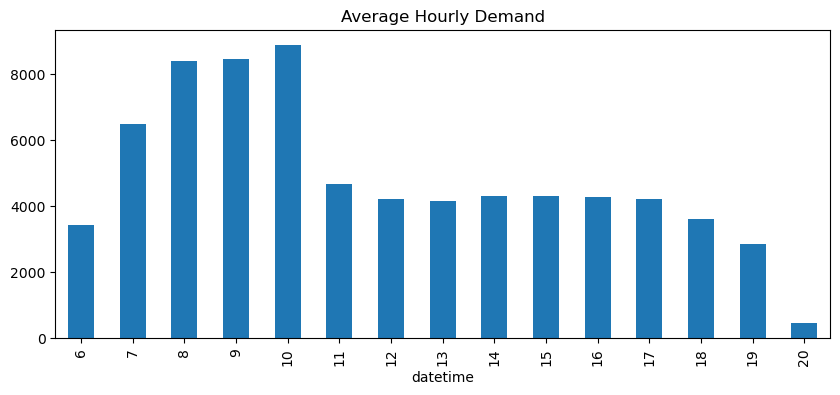

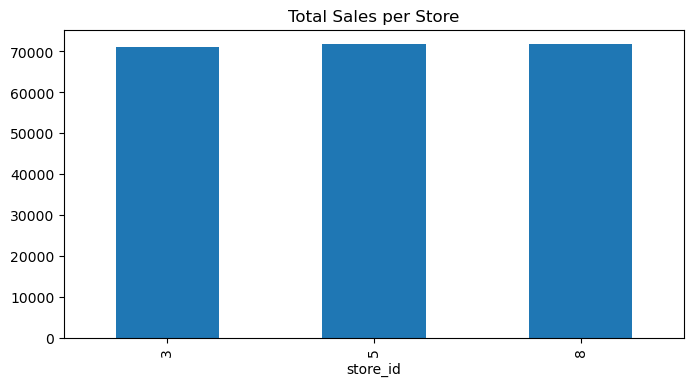

In [8]:
# Hourly Demand Pattern
hourly_filled.groupby(hourly_filled['datetime'].dt.hour)['quantity'].mean().plot(
    kind='bar', figsize=(10,4)
)
plt.title("Average Hourly Demand")
plt.show()
# Store-Level Demand
hourly_filled.groupby('store_id')['quantity'].sum().plot(
    kind='bar', figsize=(8,4)
)
plt.title("Total Sales per Store")
plt.show()


# Feature Engineering

In [9]:
df_ts = hourly_filled.copy()

df_ts['hour'] = df_ts['datetime'].dt.hour
df_ts['day_of_week'] = df_ts['datetime'].dt.dayofweek
df_ts['is_weekend'] = df_ts['day_of_week'].isin([5,6]).astype(int)


In [15]:
df_ts = df_ts.copy()

df_ts['datetime'] = pd.to_datetime(df_ts['datetime'])
df_ts = df_ts.sort_values('datetime').reset_index(drop=True)

# Time features
df_ts['hour'] = df_ts['datetime'].dt.hour
df_ts['day_of_week'] = df_ts['datetime'].dt.dayofweek
df_ts['is_weekend'] = (df_ts['day_of_week'] >= 7).astype(int)

# Lag & rolling (ONLY SAFE ONES)
df_ts['lag_1'] = df_ts['quantity'].shift(1)
df_ts['roll_3'] = df_ts['quantity'].rolling(3).mean()

# Drop NaNs ONCE
df_ts = df_ts.dropna().reset_index(drop=True)

print("After feature engineering:", df_ts.shape)


After feature engineering: (39, 10)


In [16]:
# Recalculate split AFTER feature engineering
split_index = int(len(df_ts) * 0.8)

train = df_ts.iloc[:split_index]
test = df_ts.iloc[split_index:]

print("Train length:", len(train))
print("Test length:", len(test))


Train length: 31
Test length: 8


# Train–Test Split (Time-Based)

In [17]:
train = df_ts[df_ts['datetime'] < df_ts['datetime'].max() - pd.Timedelta(days=3)]
test  = df_ts[df_ts['datetime'] >= df_ts['datetime'].max() - pd.Timedelta(days=3)]

features = ['hour', 'day_of_week', 'is_weekend',
            'lag_1', 
            'roll_3'
           ]

X_train, y_train = train[features], train['quantity']
X_test, y_test = test[features], test['quantity']


# Baseline Model (Naive Forecast)

In [18]:
y_pred_naive = test['lag_1']

mae = mean_absolute_error(y_test, y_pred_naive)
rmse = mean_squared_error(y_test, y_pred_naive, squared=False)

print("Naive MAE:", mae)
print("Naive RMSE:", rmse)


Naive MAE: 1179.7435897435898
Naive RMSE: 1627.6561881019795


# Gradient Boosting Model

In [20]:
# from sklearn.ensemble import GradientBoostingRegressor
# from sklearn.metrics import mean_absolute_error, mean_squared_error

# model = GradientBoostingRegressor(random_state=42)
# model.fit(X_train, y_train)

# y_pred = model.predict(X_test)

# mae = mean_absolute_error(y_test, y_pred)
# rmse = mean_squared_error(y_test, y_pred, squared=False)

# print("GB MAE:", mae)
# print("GB RMSE:", rmse)

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

model = GradientBoostingRegressor(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)

print("GB MAE:", mae)
print("GB RMSE:", rmse)

ValueError: Found array with 0 sample(s) (shape=(0, 5)) while a minimum of 1 is required by GradientBoostingRegressor.

# Peak Demand Detection

In [ ]:
peak_threshold = y_train.quantile(0.9)

test['actual_peak'] = y_test > peak_threshold
test['predicted_peak'] = y_pred > peak_threshold

peak_accuracy = (
    (test['actual_peak'] == test['predicted_peak']).mean()
)

print("Peak Detection Accuracy:", peak_accuracy)


In [ ]:
# print(X_train.shape, y_train.shape)
# print(X_test.shape, y_test.shape)
print("Mean quantity:", y_test.mean())
print("Max quantity:", y_test.max())



In [ ]:
mape = np.mean(np.abs((y_test - y_pred_naive) / y_test)) * 100
print("Naive MAPE:", mape)


In [ ]:
# ---- CLEAN START ----

import pandas as pd

# Ensure datetime
df_ts['datetime'] = pd.to_datetime(df_ts['datetime'])

# Sort
df_ts = df_ts.sort_values('datetime').reset_index(drop=True)

# Feature engineering
df_ts['hour'] = df_ts['datetime'].dt.hour
df_ts['day_of_week'] = df_ts['datetime'].dt.dayofweek
df_ts['is_weekend'] = (df_ts['day_of_week'] >= 5).astype(int)

df_ts['lag_1'] = df_ts['quantity'].shift(1)
df_ts['roll_3'] = df_ts['quantity'].rolling(3).mean()

# Drop NaNs
df_ts = df_ts.dropna().reset_index(drop=True)

print("Rows after FE:", len(df_ts))

# Split AFTER feature engineering
split_index = int(len(df_ts) * 0.8)

train = df_ts.iloc[:split_index]
test = df_ts.iloc[split_index:]

print("Train rows:", len(train))
print("Test rows:", len(test))


In [ ]:
print("len(df_ts):", len(df_ts))
print("len(df_ts) * 0.8:", len(df_ts) * 0.8)
print("int(len(df_ts) * 0.8):", int(len(df_ts) * 0.8))
